# Testing 21cmFast

## Initial testing

### Importing modules

In [1]:
import py21cmfast as p21c
from tempfile import mkdtemp
from pathlib import Path
from matplotlib import pyplot as plt

print(f' Using 21cmFAST version {p21c.__version__}')

 Using 21cmFAST version 4.2


### Defining Simulation inputs

The list of template configurations we want to load as defaults include:
- The configuration from Park et al. 2019 (`Park19`)
- A box with preset size and resolution

In [ ]:
"""Differences between Park19 Model and this one:

HII_DIM=512
LOWRES_CELL_SIZE_MPC=2
PERTURB_ON_HIGH_RES = True

From Meiksin 2021 and Reis et al. 2021:
- USE_CMB_HEATING = True
- USE_LYA_HEATING = True

From Qin et al. 2024 (Table 1):

- F_STAR10 = -1.42
- ALPHA_STAR = 0.51
- F_ESC10 = -1.08
- ALPHA_ESC = -0.46
- t_STAR = 0.34
- M_TURN = 8.46

This assumes a constant f_esc. Pursuing a non-constant f_esc will be optional later on.
"""

# Define inputs
scin_inputs = p21c.InputParameters.from_template(
    ["Park19", "large"], random_seed=20250303, HII_DIM=512, LOWRES_CELL_SIZE_MPC=2, N_THREADS=8
)

test_inputs = p21c.InputParameters.from_template(
    ["Park19", "large"], random_seed=20250303, HII_DIM=100, LOWRES_CELL_SIZE_MPC=2, N_THREADS=8
)

test_toml_file = "test-park19.toml"
scin_toml_file = "scin-park19.toml"

p21c.write_template(test_inputs, test_toml_file)
p21c.write_template(scin_inputs, scin_toml_file)

## Running the test lightcone file

In [3]:
cache = p21c.OutputCache(mkdtemp())

lcn = p21c.RectilinearLightconer.between_redshifts(
    min_redshift=5.5,
    max_redshift=12.0,
    quantities=("brightness_temp", "density"),
    resolution=test_inputs.simulation_options.cell_size
)

In [4]:
lightcone = p21c.run_lightcone(
    lightconer=lcn,
    inputs=test_inputs,
    cache=cache,
    progressbar=True
)

Output()

KeyboardInterrupt: 

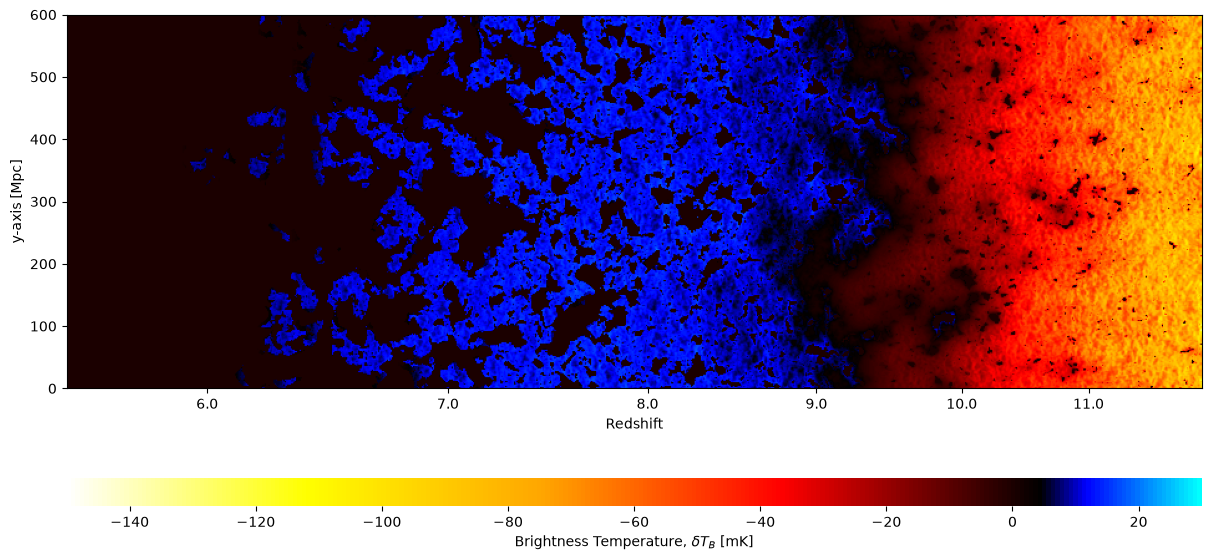

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6), constrained_layout=True)
p21c.plotting.lightcone_sliceplot(lightcone, ax=ax, fig=fig);

In [ ]:
print(lightcone.lightcones)

{'brightness_temp': array([[[   0.      ,    0.      ,    0.      , ...,  -78.12982 ,
          -78.26178 ,  -86.898056],
        [   0.      ,    0.      ,    0.      , ...,  -73.81467 ,
          -81.11486 ,  -95.111984],
        [   0.      ,    0.      ,    0.      , ...,  -66.590454,
          -76.464424,  -97.896095],
        ...,
        [   0.      ,    0.      ,    0.      , ...,  -82.1843  ,
          -96.51914 ,  -94.49663 ],
        [   0.      ,    0.      ,    0.      , ...,  -79.014275,
          -95.979614,  -96.59321 ],
        [   0.      ,    0.      ,    0.      , ...,  -81.70069 ,
          -82.31347 ,  -84.6931  ]],

       [[   0.      ,    0.      ,    0.      , ...,  -78.07287 ,
          -84.864525,  -88.41204 ],
        [   0.      ,    0.      ,    0.      , ...,  -75.98302 ,
          -83.18819 ,  -94.49526 ],
        [   0.      ,    0.      ,    0.      , ...,  -72.7042  ,
          -83.016365, -101.53809 ],
        ...,
        [   0.      ,    0.      ,